In [1]:
# pls refer to 1st model for the details of some features used in this project 

In [2]:
import matplotlib.pyplot as plt
import numpy as np


import pygimli as pg
import pygimli.meshtools as mt
from pygimli.physics import ert

In [3]:
pip install pygimli

Note: you may need to restart the kernel to use updated packages.


(<Axes: xlabel='$x$ in m', ylabel='Depth in m'>, None)

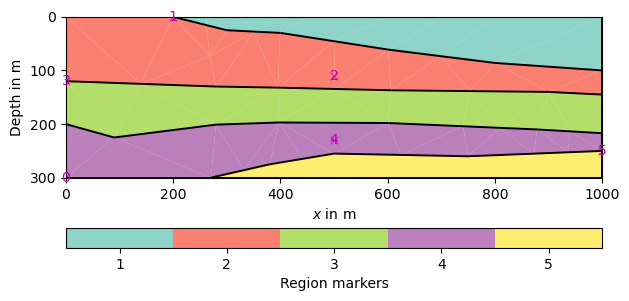

In [4]:
# Geometry def : defining the world 

world = mt.createWorld(start=[0, -300], end=[1000, 0],
                       worldMarker=True, marker = 0)

# marker info:
# world is marker 0

reg1=mt.createPolygon([(200,0), (600,0), (1000,0), (1000, -100), (800, -86), (600, -61), (400, -30), (300, -25)],
                          isClosed = True, marker = 1)

reg3 = mt.createPolygon([(0, -120), (280, -130), (395, -132), (607, -137), (900, -140), (1000, -145), (1000, -217), (879, -210), (601, -198), (397, -197), (280, -201),
                    (90, -225), (0, -200)], isClosed = True, marker = 3)

reg5 = mt.createPolygon( [(1000, -250), (1000, -300), (270, -300), (380, -275), (500, -255), (750, -260)]
                        , isClosed = True, marker = 5)

geom = world + reg1 + reg5 +reg3

geom.addRegionMarker(pos=[500, -110], marker=2) 
geom.addRegionMarker(pos=[500, -230], marker=4)

# while defining regions, remember that pygimli connects points in the order you have written 

pg.show(geom)

(<Axes: xlabel='$x$ in m', ylabel='Depth in m'>, None)

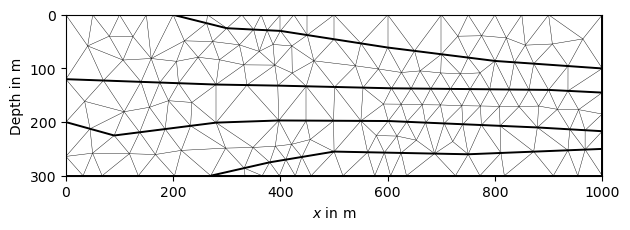

In [5]:
mesh = mt.createMesh(geom, quality=33)
pg.show(mesh, showMesh=True)

05/05/26 - 11:15:28 - pyGIMLi - INFO - Cache C:\Users\anves\anaconda3\Lib\site-packages\pygimli\physics\ert\ert.py:createGeometricFactors restored (0.0s x 73): C:\Users\anves\AppData\Roaming\pygimli\Cache\8558508383311262732


(<Axes: xlabel='$x$ in m', ylabel='Depth in m'>,
 <matplotlib.colorbar.Colorbar at 0x1c111df2d50>)

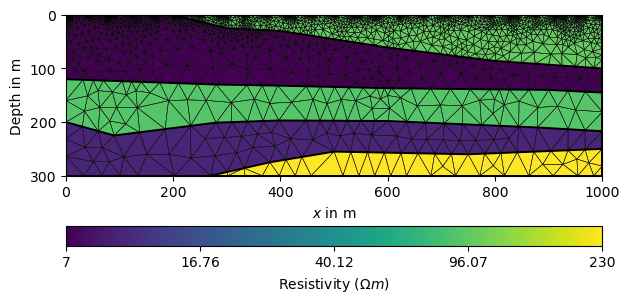

In [6]:
electrodes = np.linspace(start = 0, stop = 1000, num=25)
scheme = ert.createData(elecs=electrodes, schemeName='dd')
for p in scheme.sensors():
    geom.createNode(p)
    geom.createNode(p - [0, 0.1])
mesh = mt.createMesh(geom, quality=34)

# areas with water have more conducivity (less resistivity)
rhomap = [
    [1,100],
    [2,7],
    [3, 90],
    [4, 10],
    [5, 230]
] # 1 3 and 5 have water 
res_map = pg.solver.parseMapToCellArray(rhomap, mesh)
pg.show(mesh, res_map, label="Resistivity ($\Omega m$)", showMesh=True, logScale=True)

# virdis colour scheme 

In [7]:
scheme.save("my_geophysical_data.dat")

1

05/05/26 - 11:15:30 - pyGIMLi - INFO - Data error estimate (min:max)  0.030007699319139196 : 0.07210965832279986
05/05/26 - 11:15:30 - pyGIMLi - INFO - 0.6415017167083359 660.6582852189819
05/05/26 - 11:15:30 - pyGIMLi - INFO - Simulated data Data: Sensors: 25 data: 253, nonzero entries: ['a', 'b', 'err', 'i', 'k', 'm', 'n', 'r', 'rhoa', 'u', 'valid']
05/05/26 - 11:15:30 - pyGIMLi - INFO - The data contains: ['a', 'b', 'err', 'i', 'ip', 'iperr', 'k', 'm', 'n', 'r', 'rhoa', 'u', 'valid']
05/05/26 - 11:15:30 - pyGIMLi - INFO - Simulated rhoa (min/max) 6.301187977681777 106.32429952004368
05/05/26 - 11:15:30 - pyGIMLi - INFO - Selected data noise %(min/max) 3.00076993191392 7.210965832279986
05/05/26 - 11:15:30 - pyGIMLi - INFO - Filtered rhoa (min/max) 6.301187977681777 106.32429952004368


(<Axes: >, <matplotlib.colorbar.Colorbar at 0x1c1118d5810>)

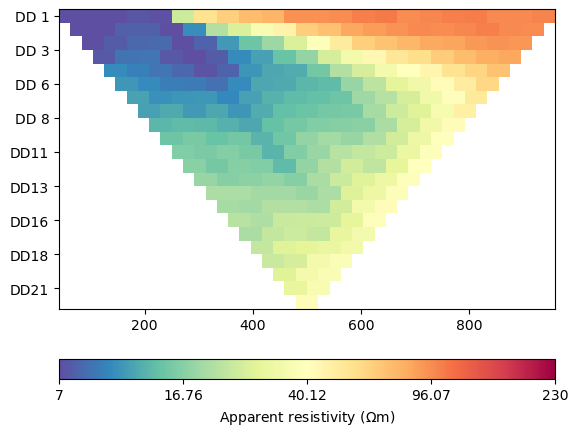

In [8]:
# forward model
data = ert.simulate(mesh, scheme=scheme, res=rhomap, noiseLevel=0.03,
                    noiseAbs=1e-6, seed=1337)

pg.info(np.linalg.norm(data['err']), np.linalg.norm(data['rhoa']))
pg.info('Simulated data', data)
pg.info('The data contains:', data.dataMap().keys())

pg.info('Simulated rhoa (min/max)', min(data['rhoa']), max(data['rhoa']))
pg.info('Selected data noise %(min/max)', min(data['err'])*100, max(data['err'])*100)

data.remove(data['rhoa'] < 0)
pg.info('Filtered rhoa (min/max)', min(data['rhoa']), max(data['rhoa']))

ert.show(data, cMin=7, cMax=230, logScale=True)
# cmin and cmax stand for colourmin and colourmax
# tell the machine that colour of cells shouldnt go beyond a particular range (to avoid unecessary outliers and noise)
# logscale = true introduces log scale of colours instead of linear scale 

In [9]:
# reverse modelling (inversion)

05/05/26 - 11:15:31 - pyGIMLi - INFO - Found 5 regions.
05/05/26 - 11:15:31 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
05/05/26 - 11:15:31 - pyGIMLi - INFO - Creating forward mesh from region infos.
05/05/26 - 11:15:31 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
05/05/26 - 11:15:31 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 14690 Cells: 27868 Boundaries: 21656
05/05/26 - 11:15:32 - pyGIMLi - INFO - Use median(data values)=20.997031383227796
05/05/26 - 11:15:32 - pyGIMLi - INFO - Created startmodel from forward operator:2110, min/max=20.997031/20.997031
05/05/26 - 11:15:32 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x000001C111BB0450>
Data transformation: Logarithmic LU transform, lower bound 0.0, upper bound 0.0
Model transformation: Logarithmic transform
min/max (data): 6.3/106
min/max (error): 5%/5.02%
min/max (start model): 21/21
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =  233.74
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =  108.04 (dPhi = 53.76%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =   47.65 (dPhi = 33.87%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =   24.24 (dPhi = 40.19%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² =   19.18 (dPhi = 2.01%) lam: 20.0
---------------------------------------------------------

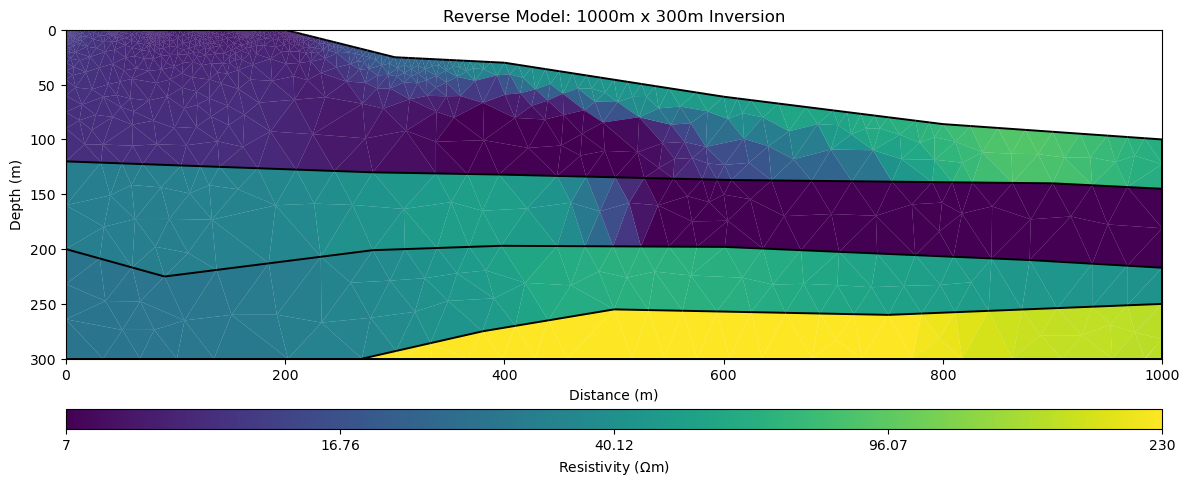

In [10]:

# 1. Error estimation at the top
data["err"] = ert.estimateError(data, relativeError=0.05, absoluteError=0.001)

# 2. Inversion
mgr = ert.ERTManager(data)
model = mgr.invert(mesh=mesh, lam=20, robustData=True, blockyModel=True, 
                   zWeight=1.0, maxIter=50, dPhi=0.01, isLoop=True, verbose=True)

# 3. DIRECT PLOTTING (Bypasses manager defaults)
fig, ax = plt.subplots(figsize=(12, 5))

# We use pg.show() directly on the mesh and model
pg.show(mgr.paraDomain, model, ax=ax, logScale=True, 
        cMin=7, cMax=230, colorMap='viridis', 
        label=r'Resistivity ($\Omega$m)')

ax.set_title("Reverse Model: 1000m x 300m Inversion")
ax.set_xlabel("Distance (m)")
ax.set_ylabel("Depth (m)")

plt.show()

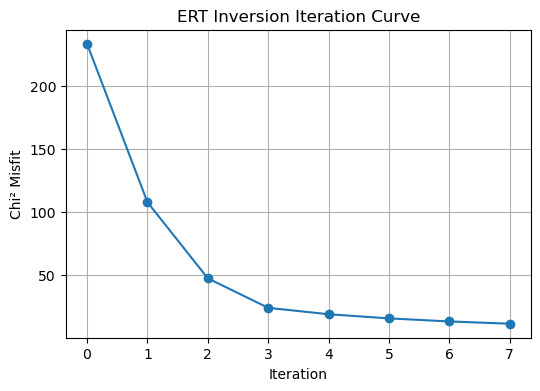

In [11]:
# generating iteration graph for the above reverse modelling
# Access inversion object
inv = mgr.inv

# Get chi-square history
chi2 = inv.chi2History
#chi2History method
# chi^2 is the measure of error/misfit

# Plot iteration graph
plt.figure(figsize=(6,4))
plt.plot(chi2, marker='o')
plt.xlabel("Iteration")
plt.ylabel("Chi² Misfit")
plt.title("ERT Inversion Iteration Curve")
plt.grid(True)
plt.show() #optimisation curve 